# World Cup Statistical Irregularities

**Goal.** Pull the full history of the men's FIFA World Cup (1930–2022) — matches, scores,
phases, referees, bookings — plus a FIFA-leadership table, and run statistical models that
surface **irregularities worth looking into**.

**What this is — and isn't.** This is an *exploratory screen*. Every number below is computed
over the same fixed slice of history, so we are making a great many comparisons at once and the
individual scores are inflated by that multiplicity. Nothing here is proof of wrongdoing; the
ranked table is a list of **leads to investigate**, with a Benjamini–Hochberg *q*-value attached
wherever a genuine statistical test exists so the multiple-testing burden is explicit.

**Method in one paragraph.** There is no reliable open historical strength rating for national
teams, so we build one in-repo: a chronological **Elo** engine over every men's World Cup match
(host nations get a home-field bonus at home only). Everything downstream — expected goals,
strength-of-schedule, host over/under-performance — hangs off those ratings. We then run five
detectors and fold their outputs into one comparable **anomaly score**.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})
# Colour-blind-safe categorical palette (Okabe–Ito).
PAL = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#F0E442", "#000000"]
pd.set_option("display.max_colwidth", 90)

from worldcup_anomalies.fetch import load_data
from worldcup_anomalies.elo import compute_elo, pre_tournament_ratings

data = load_data()                 # men's-only, cached under data/raw/
elo_matches = compute_elo(data.matches)
print("Loaded men's World Cup data and computed Elo ratings.")

Loaded men's World Cup data and computed Elo ratings.


## 1. What's in the data

The primary source is the [`jfjelstul/worldcup`](https://github.com/jfjelstul/worldcup)
normalized dataset (filtered to men's editions). Card/booking data only exists from **1970**
onward — that's a hard limit of the historical record, so the referee-discipline analysis is a
1970–2022 story. Referee *identity* and match results span the full 1930–2022.

In [2]:
display(data.summary().set_index("table"))
n_t = data.tournaments["tournament_id"].nunique()
print(f"{n_t} men's tournaments, {data.tournaments.year.min()}–{data.tournaments.year.max()}")
card_years = pd.to_datetime(data.bookings.match_date).dt.year
print(f"Card data: {card_years.min()}–{card_years.max()}  |  {len(data.referees)} referees")

,rows
table,
tournaments,22
tournament_stages,113
matches,964
goals,2720
penalty_kicks,320
bookings,2624
referees,400
referee_appearances,964
team_appearances,1928


22 men's tournaments, 1930–2022
Card data: 1970–2022  |  400 referees


## 2. The headline: irregularities worth looking into

`collect_anomalies` runs all five detectors and maps each onto a single, clipped `anomaly_score`
(a z-magnitude) so they can be ranked together. `q_value` is the Benjamini–Hochberg FDR value,
populated only where a real test exists (referee card rates, host card bias).

Read this as a triage list, top to bottom — then use the per-detector sections below to
understand *why* each item was flagged.

In [3]:
from worldcup_anomalies.anomalies import collect_anomalies

ranked = collect_anomalies(data, elo_matches)
print(f"{len(ranked)} flagged items across "
      f"{ranked.category.nunique()} detectors\n")
display(ranked.head(25).set_index("rank")[
    ["category", "subject", "detail", "anomaly_score", "q_value"]
])

75 flagged items across 6 detectors



,category,subject,detail,anomaly_score,q_value
rank,,,,,
1,upset,South Korea vs Germany,"2-0 in group stage; favourite (Elo gap 465) lost, expected ~0.6-3.0",5.000000,NaN
2,referee-cards,Ľuboš Micheľ (Slovakia),"5 matches, 39 cards vs 20 expected (7.8/match)",4.329253,0.000539
3,upset,Tunisia vs France,"1-0 in group stage; favourite (Elo gap 387) lost, expected ~0.7-2.6",4.173180,NaN
4,upset,Cameroon vs Brazil,"1-0 in group stage; favourite (Elo gap 373) lost, expected ~0.7-2.5",3.994092,NaN
5,host-performance,2022 Qatar (host),underperformed Elo by -1.5 rounds (reached group); president: Gianni Infantino,3.950501,NaN
6,host-performance,2010 South Africa (host),underperformed Elo by -1.5 rounds (reached group); president: Sepp Blatter,3.906145,NaN
7,upset,Brazil vs Norway,"1-2 in group stage; favourite (Elo gap 347) lost, expected ~2.4-0.7",3.638767,NaN
8,upset,South Korea vs Italy,"2-1 in round of 16; favourite (Elo gap 334) lost, expected ~1.0-2.4",3.468290,NaN
9,upset,Argentina vs Bulgaria,"0-2 in group stage; favourite (Elo gap 328) lost, expected ~2.3-0.8",3.395826,NaN


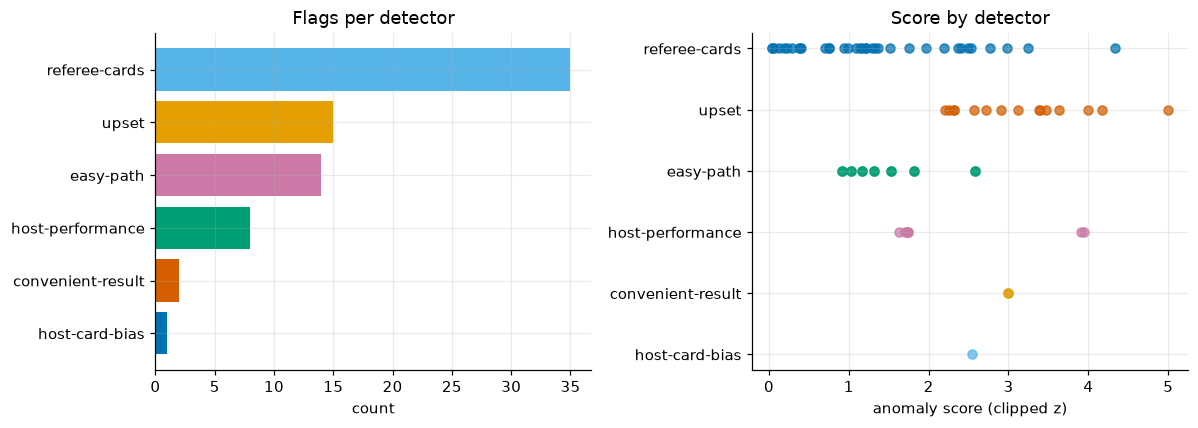

In [4]:
# How the flags distribute across detectors and severity.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
cat_order = ranked.category.value_counts()
ax1.barh(cat_order.index[::-1], cat_order.values[::-1],
         color=[PAL[i % len(PAL)] for i in range(len(cat_order))])
ax1.set_title("Flags per detector"); ax1.set_xlabel("count")

for i, cat in enumerate(cat_order.index):
    sub = ranked[ranked.category == cat]
    ax2.scatter(sub.anomaly_score, [i] * len(sub), color=PAL[i % len(PAL)],
                alpha=0.75, s=35)
ax2.set_yticks(range(len(cat_order))); ax2.set_yticklabels(cat_order.index)
ax2.set_xlabel("anomaly score (clipped z)"); ax2.set_title("Score by detector")
ax2.invert_yaxis()
plt.tight_layout(); plt.show()

## 3. Detector — Upsets (results that defied strength)

A favourite thrashing a minnow is *statistically* surprising but not interesting. What's worth a
look is the reverse: a clearly weaker side (by pre-match Elo) **winning**. We rank those by the
Elo gap the result defied. This is a sanity check as much as a detector — it should rediscover
the famous shocks, and it does (South Korea 2-0 Germany 2018, Saudi Arabia beating Argentina
2022, Cameroon over Brazil, and the 2002 South Korea run whose refereeing was itself notorious).

,year,match_name,stage_name,home_team_score,away_team_score,elo_gap_defied
0,2018,South Korea vs Germany,group stage,2,0,464.583210
1,2022,Tunisia vs France,group stage,1,0,386.998764
2,2022,Cameroon vs Brazil,group stage,1,0,373.438640
3,1998,Brazil vs Norway,group stage,1,2,346.534342
4,2002,South Korea vs Italy,round of 16,2,1,333.626240
5,1994,Argentina vs Bulgaria,group stage,0,2,328.139463
6,2022,Germany vs Japan,group stage,1,2,327.002079
7,2022,Argentina vs Saudi Arabia,group stage,1,2,307.207587
8,2018,Germany vs Mexico,group stage,0,1,291.376136
9,2002,South Korea vs Poland,group stage,2,0,276.422003


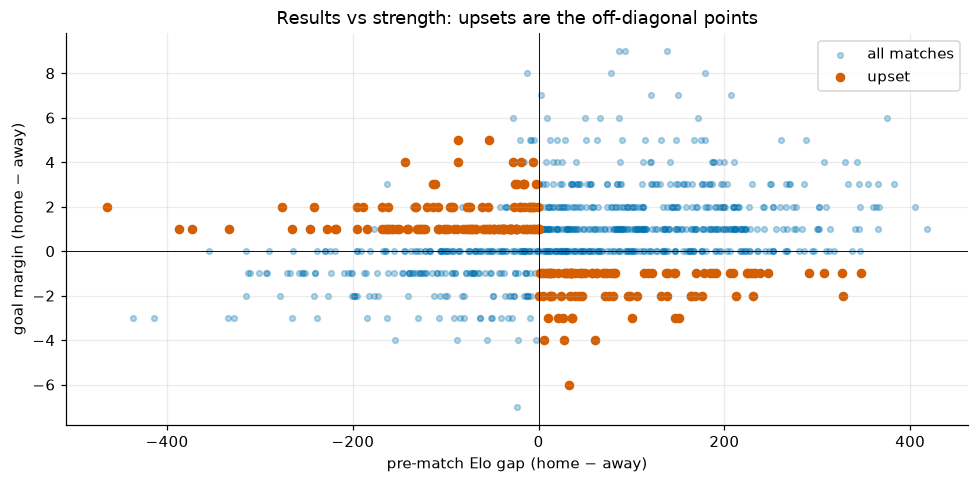

In [5]:
from worldcup_anomalies.models import score_surprise

ss = score_surprise(elo_matches, data.team_appearances)
upsets = ss[(ss.upset) & (ss.year >= 1958)].sort_values("elo_gap_defied", ascending=False)
show = upsets.head(12)[[
    "year", "match_name", "stage_name", "home_team_score", "away_team_score", "elo_gap_defied"
]]
display(show.reset_index(drop=True))

fig, ax = plt.subplots()
ax.scatter(ss.elo_home_pre - ss.elo_away_pre,
           ss.home_team_score - ss.away_team_score,
           s=14, alpha=0.3, color=PAL[0], label="all matches")
ax.scatter(upsets.elo_home_pre - upsets.elo_away_pre,
           upsets.home_team_score - upsets.away_team_score,
           s=28, color=PAL[1], label="upset")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("pre-match Elo gap (home − away)")
ax.set_ylabel("goal margin (home − away)")
ax.set_title("Results vs strength: upsets are the off-diagonal points")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Detector — "Convenient" group results

The archetype is the 1982 **Disgrace of Gijón**: West Germany beat Austria 1-0, a result that
sent *both* through at Algeria's expense, in a match played the day *after* Algeria had finished.
FIFA's response was to make final group matches kick off simultaneously from 1986 on.

The detector flags the last-played first-round group match whose result advanced **both** teams,
where a non-advancing team had already finished on an earlier day (an informational advantage).
Tellingly, it flags **only 1982** — the structure that made this possible was legislated away in
1986, and the detector independently rediscovers that.

In [6]:
from worldcup_anomalies.models import detect_convenient_results

conv = detect_convenient_results(data.matches, data.group_standings)
display(conv[[
    "tournament_id", "match_name", "match_date", "score",
    "non_simultaneous", "eliminated_finished_earlier", "suspicion"
]])
print("These are the last two World Cups (both 1982) before simultaneous final "
      "group kickoffs were mandated in 1986.")

,tournament_id,match_name,match_date,score,non_simultaneous,eliminated_finished_earlier,suspicion
0,WC-1982,West Germany vs Austria,1982-06-25,1-0,True,"Algeria, Chile",1.5
1,WC-1982,Spain vs Northern Ireland,1982-06-25,0-1,True,"Honduras, Yugoslavia",1.5


These are the last two World Cups (both 1982) before simultaneous final group kickoffs were mandated in 1986.


## 5. Detector — Referee discipline

Two questions. **(a)** Do individual referees hand out far more (or fewer) cards than the match
context warrants? We model expected cards from era, knockout-vs-group, and how competitive the
match is (by Elo), then score each referee's standardized residual. **(b)** Do **hosts** get an
easier ride from officials — fewer cards than their opponents in the matches they play?

,referee_name,referee_country,n_matches,obs_cards,exp_cards,cards_per_match,z
0,Ľuboš Micheľ,Slovakia,5,39,19.756980,7.800000,4.329253
1,Arturo Brizio Carter,Mexico,6,37,21.859719,6.166667,3.238260
2,Howard Webb,England,6,39,24.311681,6.500000,2.978959
3,César Arturo Ramos,Mexico,7,15,30.172711,2.142857,-2.762206
4,Björn Kuipers,Netherlands,7,16,29.846301,2.285714,-2.534478
5,Néstor Pitana,Argentina,9,23,38.486450,2.555556,-2.496307
6,Antonio Mateu Lahoz,Spain,5,32,20.968055,6.400000,2.409201
7,Joël Quiniou,France,7,37,25.154142,5.285714,2.361901
8,Jamal Al-Sharif,Syria,6,32,21.765194,5.333333,2.193807
9,Horacio Elizondo,Argentina,5,29,20.160041,5.800000,1.968813


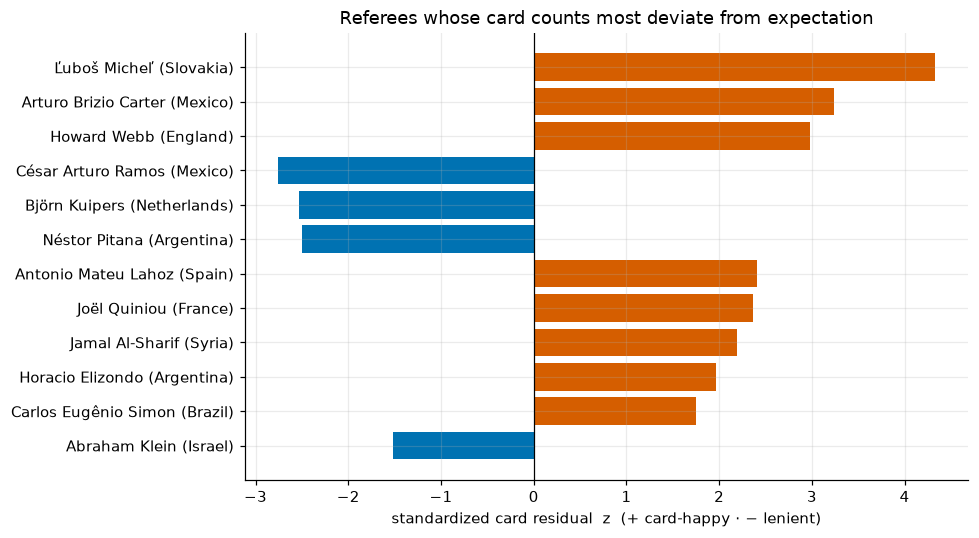

In [7]:
from worldcup_anomalies.referees import referee_outliers, host_card_bias

ro = referee_outliers(data.matches, data.referee_appearances, data.bookings,
                      elo_matches, min_matches=5)
top = ro.reindex(ro.z.abs().sort_values(ascending=False).index).head(12)
display(top[["referee_name", "referee_country", "n_matches",
             "obs_cards", "exp_cards", "cards_per_match", "z"]].reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 5))
t = top.iloc[::-1]
colors = [PAL[1] if z > 0 else PAL[0] for z in t.z]
ax.barh(t.referee_name + " (" + t.referee_country + ")", t.z, color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("standardized card residual  z  (+ card-happy · − lenient)")
ax.set_title("Referees whose card counts most deviate from expectation")
plt.tight_layout(); plt.show()

In [8]:
per_t, host_bias = host_card_bias(data.matches, data.bookings)
print("HOST CARD BIAS (matches involving the host nation, 1970+):")
for k, v in host_bias.items():
    print(f"  {k}: {v}")
print(f"\nInterpretation: in decisive matches the host received FEWER cards than its opponent "
      f"{host_bias['share_host_fewer']:.0%} of the time "
      f"(sign-test p = {host_bias['sign_test_p']:.3f}). Suggestive of a home-crowd/officiating "
      f"tilt, though card counts also reflect that hosts are often the stronger, less-pressed side.")

HOST CARD BIAS (matches involving the host nation, 1970+):
  n_decisive_matches: 51
  host_fewer_cards: 35
  host_more_cards: 16
  share_host_fewer: 0.6862745098039216
  sign_test_p: 0.010973562899720513
  total_host_cards: 116
  total_opp_cards: 158

Interpretation: in decisive matches the host received FEWER cards than its opponent 69% of the time (sign-test p = 0.011). Suggestive of a home-crowd/officiating tilt, though card counts also reflect that hosts are often the stronger, less-pressed side.


## 6. Detector — "Easy path" / seeding luck

For every team that reached the quarter-final or deeper, we measure the strength of the teams it
actually had to beat — the mean pre-tournament Elo of its opponents — and how many established
"powers" (top-quartile that edition) it faced. A run to the semi-final or final past unusually
weak opposition is a lucky/soft draw, *whether or not* the team was the host.

We compare within the round reached (finalists vs finalists) and skip 1930–1938, where every
team enters at the base rating and opponent strength is meaningless (Elo cold-start).

Easiest routes to the FINAL:


,year,team_name,mean_opp_elo,max_opp_elo,n_powers_faced,easiness_pct
0,1962,Brazil,1476.025641,1523.154586,0,100.000000
1,2002,Germany,1476.538258,1770.472967,1,97.058824
2,1986,West Germany,1495.577169,1598.891022,0,94.117647
3,2022,France,1505.788189,1654.969388,1,91.176471
4,1974,West Germany,1505.919376,1567.541617,1,88.235294
5,1958,Brazil,1514.291639,1596.106917,1,85.294118


Easiest routes to the SEMI-FINAL:


,year,team_name,mean_opp_elo,max_opp_elo,n_powers_faced,easiness_pct
0,1974,Brazil,1491.301517,1544.259241,0,100.000000
1,1958,West Germany,1512.213909,1564.483552,0,97.058824
2,1986,Belgium,1513.331330,1617.892112,0,94.117647
3,1970,West Germany,1519.249537,1613.823834,1,91.176471
4,2018,England,1522.161014,1574.366105,1,88.235294
5,1958,France,1535.528869,1645.169287,2,85.294118


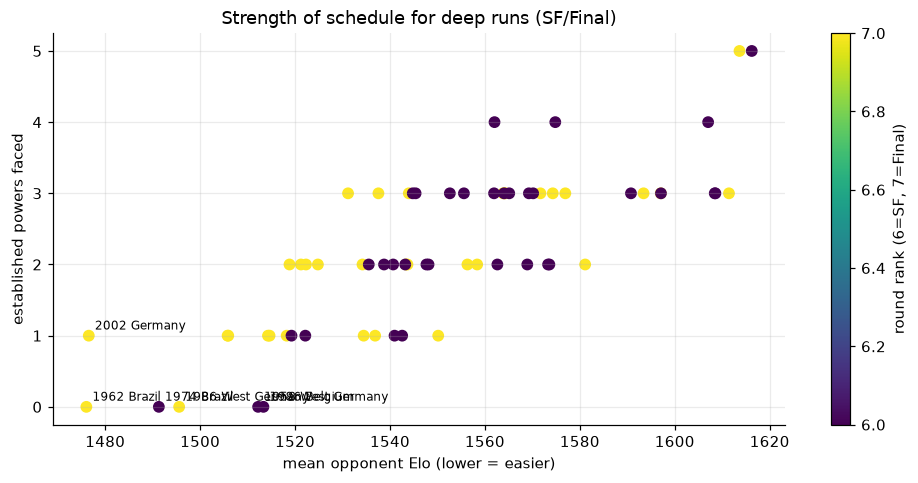

In [9]:
from worldcup_anomalies.paths import easy_path_scores

ep = easy_path_scores(elo_matches, data.team_appearances)
finals = ep[ep.round_label == "Final"].sort_values("mean_opp_elo").head(6)
semis = ep[ep.round_label == "SF"].sort_values("mean_opp_elo").head(6)
print("Easiest routes to the FINAL:")
display(finals[["year", "team_name", "mean_opp_elo", "max_opp_elo",
                "n_powers_faced", "easiness_pct"]].reset_index(drop=True))
print("Easiest routes to the SEMI-FINAL:")
display(semis[["year", "team_name", "mean_opp_elo", "max_opp_elo",
               "n_powers_faced", "easiness_pct"]].reset_index(drop=True))

deep = ep[ep.round_rank >= 6].copy()
fig, ax = plt.subplots()
sc = ax.scatter(deep.mean_opp_elo, deep.n_powers_faced,
                c=deep.round_rank, cmap="viridis", s=45)
for _, r in pd.concat([finals.head(3), semis.head(3)]).iterrows():
    ax.annotate(f"{int(r.year)} {r.team_name}",
                (r.mean_opp_elo, r.n_powers_faced), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("mean opponent Elo (lower = easier)")
ax.set_ylabel("established powers faced")
ax.set_title("Strength of schedule for deep runs (SF/Final)")
plt.colorbar(sc, label="round rank (6=SF, 7=Final)")
plt.tight_layout(); plt.show()

## 7. Detector — FIFA leadership lens (exploratory)

The most speculative view: map each tournament to the FIFA president in office and ask whether
over/under-performance clusters by era. **This is correlational and under-powered** — 22
tournaments across 7 presidents — so treat it as a conversation-starter, not a finding.

The honest result: host over-performance is *higher* in the early decades (when hosting carried a
huge travel/familiarity edge) and *lower* under Blatter/Infantino. The "corruption-era host bias"
hypothesis is **not** supported by the data.

,president,n_tournaments,host_titles,mean_host_overperf,host_reached_final,host_reached_semi
0,Jules Rimet,5,2,2.444008,2,3
1,Arthur Drewry,1,0,3.374891,1,1
2,Stanley Rous,3,1,2.760021,1,2
3,João Havelange,6,2,1.990252,2,3
4,Sepp Blatter,5,1,0.796913,1,3
5,Gianni Infantino,2,0,0.071681,0,0


Permutation test — host over-performance in the Havelange+Blatter era vs the rest:
  observed difference: -0.74 rounds   p = 0.885
  → no evidence hosts over-performed MORE in that era (if anything, less).


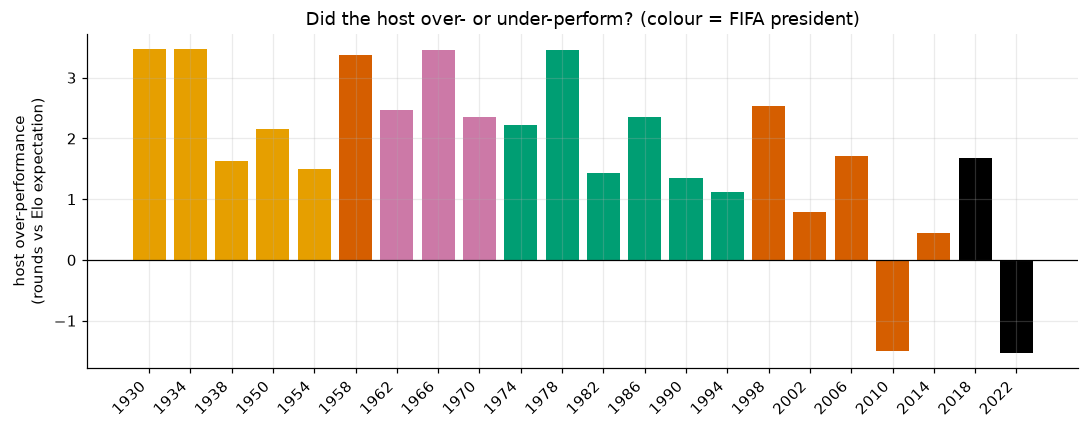

In [10]:
from worldcup_anomalies.leadership import (
    era_summary, host_overperformance, host_overperformance_permutation,
)

es = era_summary(data.tournaments, elo_matches, data.team_appearances, data.leadership)
display(es)

ho = host_overperformance(data.tournaments, elo_matches, data.team_appearances, data.leadership)
perm = host_overperformance_permutation(ho, ["João Havelange", "Sepp Blatter"], n_perm=20000)
print("Permutation test — host over-performance in the Havelange+Blatter era vs the rest:")
print(f"  observed difference: {perm['observed_diff']:+.2f} rounds   p = {perm['p_value']:.3f}")
print("  → no evidence hosts over-performed MORE in that era (if anything, less).")

fig, ax = plt.subplots(figsize=(10, 4))
ho_s = ho.sort_values("year")
colors = [PAL[hash(p) % len(PAL)] for p in ho_s.president]
ax.bar(ho_s.year.astype(str), ho_s.overperformance, color=colors)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("host over-performance\n(rounds vs Elo expectation)")
ax.set_title("Did the host over- or under-perform? (colour = FIFA president)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

## 8. Takeaways

- The screen **rediscovers known cases**, which is the point of validating it: the 1982 Gijón
  match tops the convenient-result detector, the 2018 Germany and 2022 Saudi/Argentina shocks top
  the upset detector, and the 2002 South Korea run (notorious for its officiating) surfaces near
  the top of the combined table.
- The one **systemic signal with a real test behind it** is host card bias: hosts receive fewer
  cards than their opponents about 69% of the time (sign-test p ≈ 0.01, BH q ≈ 0.06). Worth a
  deeper, confounder-aware look — hosts are also often the stronger, more possession-dominant side.
- Individual **referee card rates** vary far more than context explains (e.g. very card-happy vs
  very lenient officials), with small-sample caveats — several survive BH correction.
- The **FIFA-leadership lens returns a null**: no era-clustering of host over-performance. Reported
  as-is, because a screen that only ever confirms its priors is worthless.

**Caveats.** Elo is inferred from World Cup matches only (no qualifiers/friendlies), so early
ratings are noisy. Card data starts in 1970. Above all this is a multiple-comparison screen: the
q-values quantify how much of the apparent signal survives that. Treat every row as a lead, not a
verdict.